In [1]:
suppressMessages(library("rwwa"))

In [35]:
fit_copula_v2 <- function(mdl_x, mdl_y, new_data) {

  # if no new data provided, create DF of new data from marginal models
  if(missing(new_data)) new_data <- merge(mdl_x$data, mdl_y$data)

  # transform marginals to U
  u_x <- map_to_u(mdl_x, x = new_data[,mdl_x$varnm], fixed_cov = new_data[,mdl_x$covnm, drop = F])
  u_y <- map_to_u(mdl_y, x = new_data[,mdl_y$varnm], fixed_cov = new_data[,mdl_y$covnm, drop = F])

  # Fit the copula and extract a copula object - need to generalise this
  # if(is(copulatype, "tCopula")) {
  fitted_copula <- fitCopula(tCopula(), data = cbind(u_x, u_y), hideWarnings = T)
  cfit <- tCopula(coef(fitted_copula)["rho.1"], df = round(coef(fitted_copula)["df"],0), df.fixed = T) # integer DF needed for eg. pCopula & goodness of fit
  # } else {
  #   print("Copula type not yet implemented")
  #   return(NULL)
  # }

  # output
  return(list(mdl_x = mdl_x, mdl_y = mdl_y, copula = cfit, new_data = new_data))
}

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
plot_fitted_copula_v2 <- function(joint_model, levels = c(0.5,1,1.5), add_sample = F, ...) {

  # transform marginals to U
  u_x <- map_to_u(joint_model$mdl_x, x = joint_model$new_data[,mdl_x$varnm], fixed_cov = joint_model$new_data[,mdl_x$covnm, drop = F])
  u_y <- map_to_u(joint_model$mdl_y, x = joint_model$new_data[,mdl_y$varnm], fixed_cov = joint_model$new_data[,mdl_y$covnm, drop = F])

  plot(u_x, u_y, col = "black", pch = 20, xlab = paste0("u_",joint_model$mdl_x$varnm), ylab = paste0("u_",joint_model$mdl_y$varnm), xaxs = "i", yaxs = "i", ...)

  if(add_sample) {
    # generate sample from the copula
    samp <- rCopula(length(u_x), joint_model$copula)
    points(samp, col = "cornflowerblue", pch = 1)
  }

  contour(kde2d(u_x, u_y), col = "black", add = T, levels = levels)
  contour(joint_model$copula, dCopula, add = T, col = "cornflowerblue", lty = 2, levels = levels)
}

## Joint modelling with multiple events per year

In [3]:
gmst <- read.table("gmst.txt", col.names = c("year", "gmst"))

In [4]:
tp <- read.csv("hot_box_1_precip_ts_era5.csv")
tmax <- read.csv("hot_box_30_temp_ts_era5.csv")

In [57]:
new_data = read.csv("new_data.csv")
new_data$tmax <- new_data$tmax - 2

In [58]:
mdl_tp <- fit_ns(dist = "gev", type = "fixeddisp", data = merge(gmst, tp), varnm = "tp", covnm = "gmst")
mdl_tmax <- fit_ns(dist = "gev", type = "shift", data = merge(gmst, tmax), varnm = "tmax", covnm = "gmst")

In [59]:
# standard copula fitted to single event per year
mdl_joint <- fit_copula(mdl_tp, mdl_tmax)

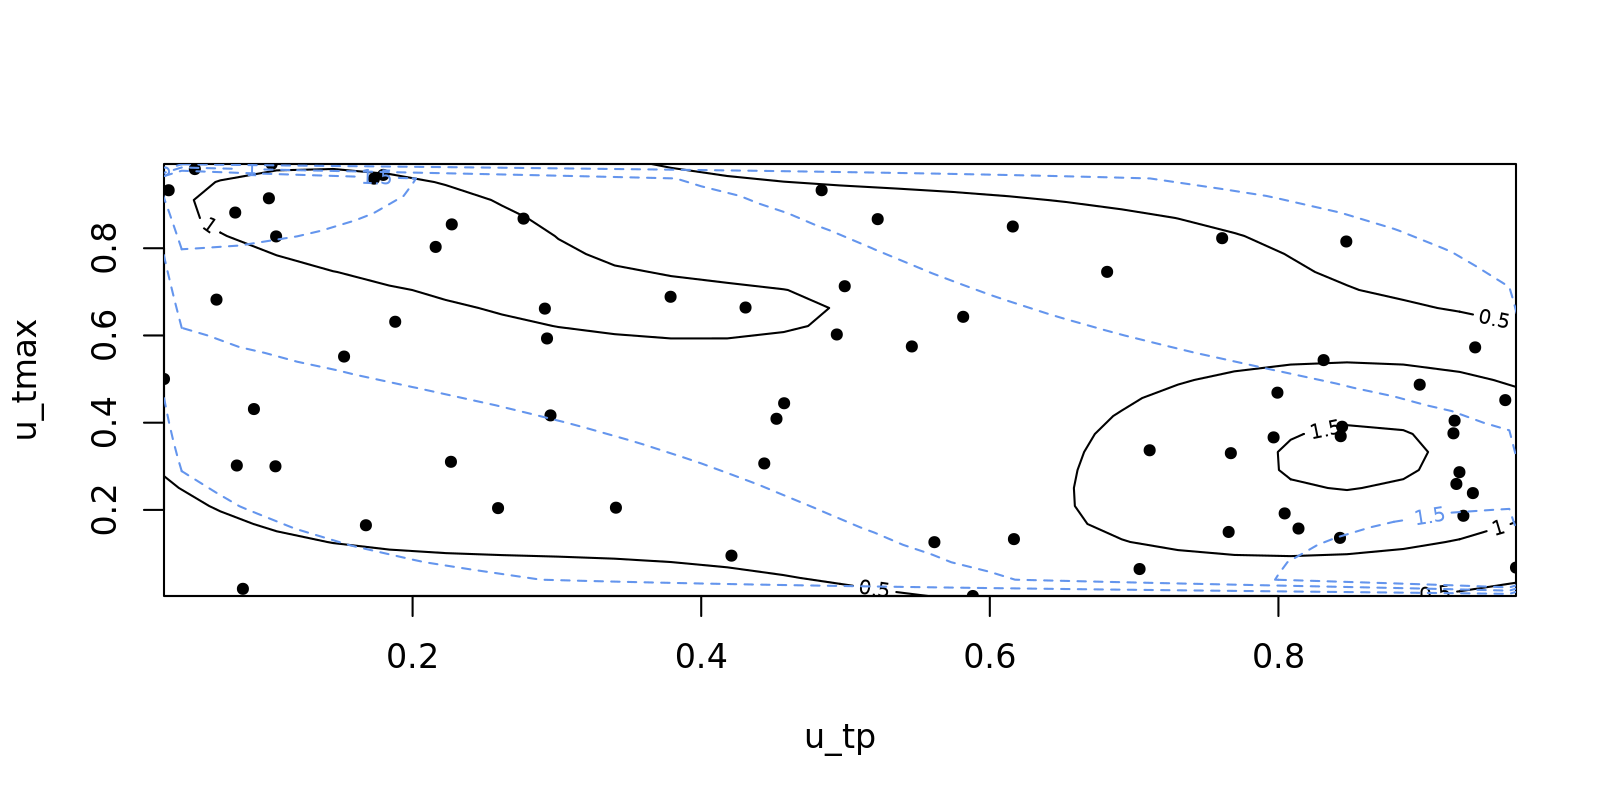

In [60]:
plot_fitted_copula(mdl_joint)

In [78]:
joint_model <- fit_copula_2(mdl_tp, mdl_tmax, new_data = new_data)

In [80]:
# transform marginals to U
  u_x <- map_to_u(joint_model$mdl_x, x = joint_model$new_data[,mdl_x$varnm], fixed_cov = joint_model$new_data[,mdl_x$covnm, drop = F])
  u_y <- map_to_u(joint_model$mdl_y, x = joint_model$new_data[,mdl_y$varnm], fixed_cov = joint_model$new_data[,mdl_y$covnm, drop = F])

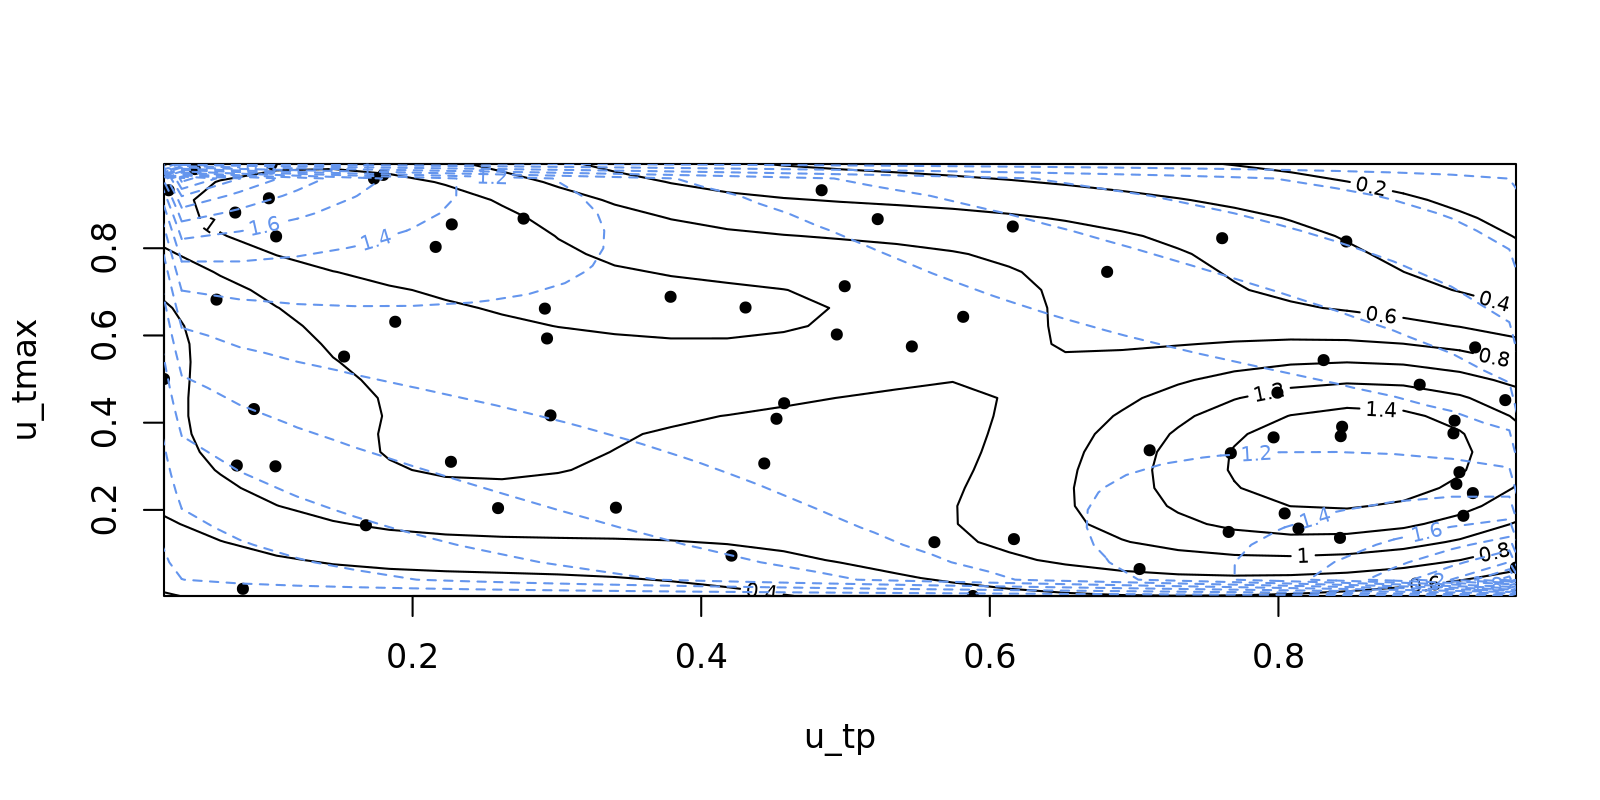

In [85]:
  plot(u_x, u_y, col = "black", pch = 20, xlab = paste0("u_",joint_model$mdl_x$varnm), ylab = paste0("u_",joint_model$mdl_y$varnm), xaxs = "i", yaxs = "i")

  # if(add_sample) {
  #   # generate sample from the copula
  #   samp <- rCopula(length(u_x), joint_model$copula)
  #   points(samp, col = "cornflowerblue", pch = 1)
  # }

  contour(kde2d(u_x, u_y), col = "black", add = T)
  contour(joint_model$copula, dCopula, add = T, col = "cornflowerblue", lty = 2)

In [ ]:
  # Fit the copula and extract a copula object - need to generalise this
  # if(is(copulatype, "tCopula")) {
  fitted_copula <- fitCopula(tCopula(), data = cbind(u_x, u_y), hideWarnings = T)
  cfit <- tCopula(coef(fitted_copula)["rho.1"], df = round(coef(fitted_copula)["df"],0), df.fixed = T) # integer DF needed for eg. pCopula & goodness of fit
  # } else {
  #   print("Copula type not yet implemented")
  #   return(NULL)
  # }

  # output
  return(list(mdl_x = mdl_x, mdl_y = mdl_y, copula = cfit, new_data = new_data))